# KAN Semi-Infinite-Domain Hyperparameter Optimization Plot

Load the completed semi-infinite KAN Optuna study and plot its optimization history and hyperparameter slices.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm, Normalize

In [13]:
# Select the completed semi-infinite KAN study.
results_dir = Path("results_kan_semi_infinite_optuna_2026-09-20_20-46-49")
study_path = results_dir / "data" / "study.csv"
if not study_path.exists():
    raise FileNotFoundError(f"Study file not found: {study_path}")

trials = pd.read_csv(study_path)
trials = trials[trials["state"].eq("COMPLETE")].copy()
trials["objective"] = trials["value"]
trials = trials[trials["objective"] > 0].sort_values("number").reset_index(drop=True)
if trials.empty:
    raise ValueError("The selected KAN result file has no positive completed objectives.")

best_trial = trials.loc[trials["objective"].idxmin()]
print(f"Source: {study_path}")
print(f"Best objective: {best_trial['objective']:.6e}")
for name in ("hidden_layers", "hidden_units", "grid_size", "spline_order", "learning_rate"):
    print(f"{name}: {best_trial[f'params_{name}']}")

Source: results_kan_semi_infinite_optuna_2026-09-20_20-46-49/data/study.csv
Best objective: 8.376314e-04
hidden_layers: 3
hidden_units: 15
grid_size: 5
spline_order: 3
learning_rate: 0.01


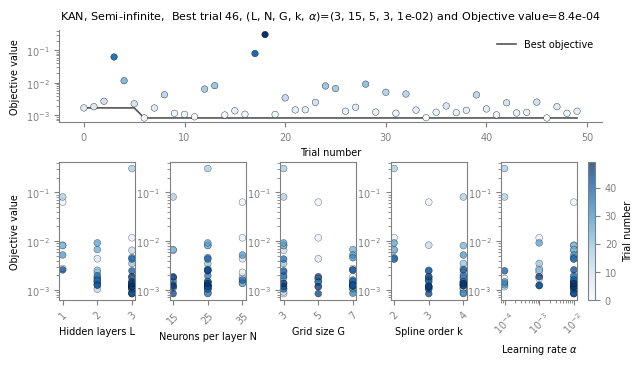

In [14]:
parameter_columns = {
    "hidden_layers": "params_hidden_layers",
    "hidden_units": "params_hidden_units",
    "grid_size": "params_grid_size",
    "spline_order": "params_spline_order",
    "learning_rate": "params_learning_rate",
}

axis_color = "#808080"
fig = plt.figure(figsize=(7, 3.5))
grid = fig.add_gridspec(2, 1, height_ratios=(1.2, 1.8), hspace=0.35)

ax_history = fig.add_subplot(grid[0, 0])
best_values = trials["objective"].cummin()
objective_min = trials["objective"].min()
objective_max = trials["objective"].max()
objective_norm = LogNorm(vmin=objective_min, vmax=max(objective_max, objective_min * 1.01))
ax_history.plot(trials["number"], best_values, color="#555555", linewidth=1.2, label="Best objective")
ax_history.scatter(trials["number"], trials["objective"], c=trials["objective"], cmap="Blues", norm=objective_norm, edgecolors="black", linewidths=0.25, s=22, zorder=2)
best_configuration = (
    f"KAN, Semi-infinite,  Best trial {int(best_trial['number'])}, "
    f"(L, N, G, k, $\\alpha$)=({int(best_trial['params_hidden_layers'])},"
    f" {int(best_trial['params_hidden_units'])},"
    f" {int(best_trial['params_grid_size'])},"
    f" {int(best_trial['params_spline_order'])},"
    f" {best_trial['params_learning_rate']:.0e}) and "
    f"Objective value={best_trial['objective']:.1e}"
)
ax_history.set_title(best_configuration, fontsize=8, pad=8)
ax_history.spines["top"].set_visible(False)
ax_history.spines["right"].set_visible(False)
ax_history.set_yscale("log")
ax_history.set_ylabel("Objective value", fontsize=7)
ax_history.set_xlabel("Trial number", fontsize=7)
ax_history.legend(frameon=False, fontsize=7)
ax_history.tick_params(axis="both", which="both", labelsize=7, colors=axis_color)
for spine in ax_history.spines.values():
    spine.set_color(axis_color)

parameters = list(parameter_columns)
slice_grid = grid[1, 0].subgridspec(1, len(parameters), wspace=0.45)
axes = [fig.add_subplot(slice_grid[0, index]) for index in range(len(parameters))]
trial_norm = Normalize(trials["number"].min(), trials["number"].max())
labels = {"hidden_layers": "Hidden layers L", "hidden_units": "Neurons per layer N", "grid_size": "Grid size G", "spline_order": "Spline order k", "learning_rate": r"Learning rate $\alpha$"}

for index, (name, column) in enumerate(parameter_columns.items()):
    axis = axes[index]
    values = pd.to_numeric(trials[column])
    scatter = axis.scatter(values, trials["objective"], c=trials["number"], cmap="Blues", norm=trial_norm, edgecolors="black", linewidths=0.25, alpha=0.75, s=24)
    axis.set_yscale("log")
    axis.set_xlabel(labels[name], fontsize=7)
    if index == 0:
        axis.set_ylabel("Objective value", fontsize=7)
    axis.tick_params(axis="both", which="both", labelsize=7, colors=axis_color)
    for spine in axis.spines.values():
        spine.set_color(axis_color)
    if name == "learning_rate":
        axis.set_xscale("log")
    if values.nunique() <= 10:
        axis.set_xticks(sorted(values.unique()))
        axis.tick_params(axis="x", rotation=45)

colorbar = fig.colorbar(scatter, ax=axes, pad=0.02, fraction=0.025)
colorbar.set_label("Trial number", fontsize=7, color='black')
colorbar.ax.tick_params(labelsize=7, colors=axis_color)
colorbar.outline.set_edgecolor(axis_color)

figure_dir = Path("figures")
figure_dir.mkdir(exist_ok=True)
plt.savefig(figure_dir / "kan_semi_infinite_hyperparameter_optimization.svg", dpi=300, bbox_inches="tight")
plt.savefig(figure_dir / "kan_semi_infinite_hyperparameter_optimization.pdf", dpi=300, bbox_inches="tight")
plt.show()